# 03 — Algoritmos Genéticos

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

- representar soluciones mediante cromosomas;
- implementar selección, cruce y mutación;
- observar la evolución de una población;
- analizar el balance entre exploración y explotación.

![HillClimbing](https://drive.google.com/uc?export=view&id=1XSZ2ppaVR85ZRJErD0-0tB4aP26ReY5H)

## 1. Problema OneMax

Cada individuo es una cadena binaria de longitud $L$. Queremos maximizar el número de unos:

$$
\text{fitness}(x)=\sum_{i=1}^{L}x_i
$$

El óptimo global es una cadena formada completamente por unos. Es un problema sencillo, pero permite observar con claridad todos los componentes de un algoritmo genético.

In [14]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 14
random.seed(SEED)
np.random.seed(SEED)


def create_individual(length, rng):
    return [rng.randint(0, 1) for _ in range(length)]


def fitness(individual):
    return sum(individual)


def as_string(individual):
    return ''.join(map(str, individual))

rng = random.Random(SEED)
example = create_individual(20, rng)
print(as_string(example), 'fitness =', fitness(example))

00111011111010111100 fitness = 13


## 2. Selección por torneo

Elegimos varios individuos al azar y seleccionamos el de mayor fitness. El tamaño del torneo controla la **presión de selección**.

In [15]:
def tournament_selection(population, tournament_size, rng):
    contestants = rng.sample(population, tournament_size)
    return max(contestants, key=fitness).copy()

population = [create_individual(12, rng) for _ in range(8)]
selected = tournament_selection(population, tournament_size=3, rng=rng)
print('Seleccionado:', as_string(selected), 'fitness =', fitness(selected))

Seleccionado: 110111111001 fitness = 9


## 3. Cruce de un punto

Dos padres intercambian fragmentos de sus cromosomas.

In [16]:
def one_point_crossover(parent1, parent2, crossover_rate, rng):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    point = rng.randint(1, len(parent1) - 1)
    child1 = parent1[:point] + parent2[point:]
    child2 = parent2[:point] + parent1[point:]
    return child1, child2

p1 = [1, 1, 1, 1, 0, 0, 0, 0]
p2 = [0, 0, 0, 0, 1, 1, 1, 1]
c1, c2 = one_point_crossover(p1, p2, 1.0, rng)
print('Padre 1:', as_string(p1))
print('Padre 2:', as_string(p2))
print('Hijo 1 :', as_string(c1))
print('Hijo 2 :', as_string(c2))

Padre 1: 11110000
Padre 2: 00001111
Hijo 1 : 11110111
Hijo 2 : 00001000


## 4. Mutación

Cada bit cambia con probabilidad $p_m$. La mutación introduce diversidad y puede recuperar información genética que desapareció de la población.

In [17]:
def mutate(individual, mutation_rate, rng):
    child = individual.copy()
    for i in range(len(child)):
        if rng.random() < mutation_rate:
            child[i] = 1 - child[i]
    return child

before = [0] * 20
after = mutate(before, mutation_rate=0.15, rng=rng)
print('Antes  :', as_string(before))
print('Después:', as_string(after))

Antes  : 00000000000000000000
Después: 00000000000010001011


## 5. Algoritmo genético completo

Incluiremos **elitismo**: el mejor individuo pasa directamente a la siguiente generación.

In [18]:
def genetic_algorithm(
    chromosome_length=40,
    population_size=60,
    generations=100,
    crossover_rate=0.9,
    mutation_rate=None,
    tournament_size=3,
    elitism=True,
    seed=0
):
    if mutation_rate is None:
        mutation_rate = 1 / chromosome_length

    rng = random.Random(seed)
    population = [create_individual(chromosome_length, rng)
                  for _ in range(population_size)]
    history = []

    for generation in range(generations + 1):
        fitnesses = [fitness(ind) for ind in population]
        best_index = int(np.argmax(fitnesses))
        best = population[best_index].copy()

        history.append({
            'generation': generation,
            'best': max(fitnesses),
            'mean': float(np.mean(fitnesses)),
            'diversity': len({tuple(ind) for ind in population}) / population_size,
            'best_individual': best
        })

        if fitness(best) == chromosome_length or generation == generations:
            break

        new_population = [best] if elitism else []

        while len(new_population) < population_size:
            parent1 = tournament_selection(population, tournament_size, rng)
            parent2 = tournament_selection(population, tournament_size, rng)
            child1, child2 = one_point_crossover(parent1, parent2, crossover_rate, rng)
            child1 = mutate(child1, mutation_rate, rng)
            child2 = mutate(child2, mutation_rate, rng)
            new_population.extend([child1, child2])

        population = new_population[:population_size]

    return history[-1]['best_individual'], history

best, history = genetic_algorithm(seed=SEED)
print('Mejor individuo:', as_string(best))
print('Fitness:', fitness(best), '/', len(best))
print('Generaciones ejecutadas:', history[-1]['generation'])

Mejor individuo: 1111111111111111111111111111111111111111
Fitness: 40 / 40
Generaciones ejecutadas: 16


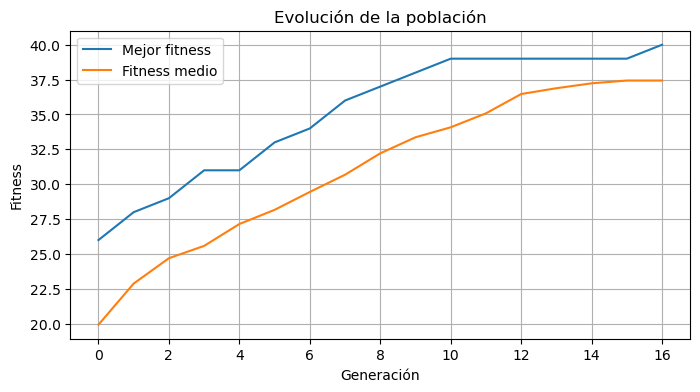

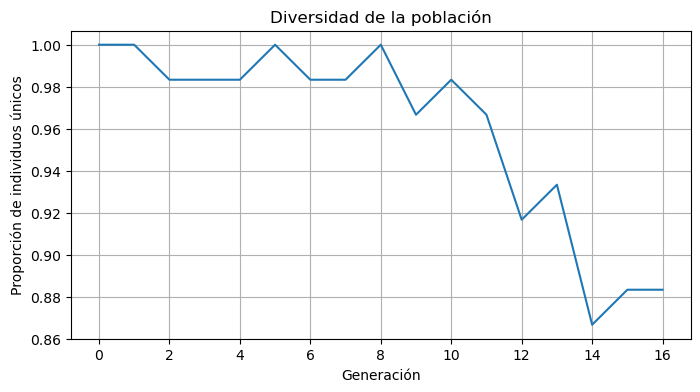

In [19]:
generations = [h['generation'] for h in history]
best_values = [h['best'] for h in history]
mean_values = [h['mean'] for h in history]

plt.figure(figsize=(8, 4))
plt.plot(generations, best_values, label='Mejor fitness')
plt.plot(generations, mean_values, label='Fitness medio')
plt.xlabel('Generación')
plt.ylabel('Fitness')
plt.title('Evolución de la población')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(generations, [h['diversity'] for h in history])
plt.xlabel('Generación')
plt.ylabel('Proporción de individuos únicos')
plt.title('Diversidad de la población')
plt.grid(True)
plt.show()

## 6. Efecto de la mutación

Una tasa muy baja puede producir convergencia prematura. Una tasa muy alta destruye las estructuras que el cruce intenta conservar.

In [20]:
rates = [0.0, 0.005, 0.025, 0.1, 0.5]
summary = []

for rate in rates:
    final_fitness = []
    generations_used = []
    for seed in range(20):
        best, hist = genetic_algorithm(
            chromosome_length=40,
            generations=120,
            mutation_rate=rate,
            seed=seed
        )
        final_fitness.append(fitness(best))
        generations_used.append(hist[-1]['generation'])
    summary.append((rate, np.mean(final_fitness), np.mean(generations_used)))

print('mutation_rate | fitness medio | generaciones medias')
for row in summary:
    print(f'{row[0]:>13.3f} | {row[1]:>13.2f} | {row[2]:>18.2f}')

mutation_rate | fitness medio | generaciones medias
        0.000 |         37.65 |             114.85
        0.005 |         40.00 |              19.90
        0.025 |         40.00 |              16.45
        0.100 |         38.45 |             117.00
        0.500 |         31.75 |             120.00


## Actividades

### Actividad 1 — Selección por ruleta

Implementa selección proporcional al fitness. Ten cuidado con poblaciones donde todos los individuos tengan fitness cero.

In [21]:
def roulette_selection(population, rng):
    fitnesses = [fitness(ind) for ind in population]
    total_fitness = sum(fitnesses)

    if total_fitness == 0:
        return rng.choice(population).copy()

    pick = rng.random() * total_fitness
    accumulated = 0
    for ind, value in zip(population, fitnesses):
        accumulated += value
        if accumulated >= pick:
            return ind.copy()

    return population[-1].copy()

population = [create_individual(12, rng) for _ in range(8)]
demo_rng = random.Random(SEED)
print('Población inicial:')
for ind in population:
    print(as_string(ind), 'fitness =', fitness(ind))

selected = roulette_selection(population, demo_rng)
print('Seleccionado:', as_string(selected), 'fitness =', fitness(selected))

draws = 10000
counts = {}
for _ in range(draws):
    winner = as_string(roulette_selection(population, demo_rng))
    counts[winner] = counts.get(winner, 0) + 1

total_fitness = sum(fitness(ind) for ind in population)
print(f' frecuencia de seleccion en {draws} sorteos:')

for ind in population:
    key = as_string(ind)
    observed = counts.get(key, 0)
    expected = draws * fitness(ind) / total_fitness if total_fitness > 0 else draws / len(population)
    print(f'{key} fitness = {fitness(ind)}: observado = {observed}, esperado = {expected:.2f}')

all_zeros = [[0] * 12 for _ in range(4)]
print('caso fitness total 0:', as_string(roulette_selection(all_zeros, demo_rng)))

Población inicial:
001110100111 fitness = 7
101000000010 fitness = 3
111110100010 fitness = 7
000010010011 fitness = 4
101010100010 fitness = 5
011111101011 fitness = 9
010011111100 fitness = 7
110100001000 fitness = 4
Seleccionado: 001110100111 fitness = 7
 frecuencia de seleccion en 10000 sorteos:
001110100111 fitness = 7: observado = 1500, esperado = 1521.74
101000000010 fitness = 3: observado = 638, esperado = 652.17
111110100010 fitness = 7: observado = 1545, esperado = 1521.74
000010010011 fitness = 4: observado = 877, esperado = 869.57
101010100010 fitness = 5: observado = 1062, esperado = 1086.96
011111101011 fitness = 9: observado = 1912, esperado = 1956.52
010011111100 fitness = 7: observado = 1567, esperado = 1521.74
110100001000 fitness = 4: observado = 899, esperado = 869.57
caso fitness total 0: 000000000000


### Actividad 2 — Cruce uniforme

En cada posición, el hijo toma el gen del padre 1 o del padre 2 con igual probabilidad.

In [22]:
def cut_points(child):
    return sum(1 for i in range(1, len(child)) if child[i] != child[i - 1])

In [23]:
def uniform_crossover(parent1, parent2, crossover_rate, rng):
    if rng.random() >= crossover_rate:
        return parent1.copy(), parent2.copy()

    child1 = []
    child2 = []

    for gene1, gene2 in zip(parent1, parent2):
        if rng.random() < 0.5:
            child1.append(gene1)
            child2.append(gene2)
        else:
            child1.append(gene2)
            child2.append(gene1)
    return child1, child2

demo_rng = random.Random(SEED)
p1 = [1] * 16
p2 = [0] * 16

c1, c2 = uniform_crossover(p1, p2, crossover_rate=1.0, rng=demo_rng)
print('Padre 1:', as_string(p1))
print('Padre 2:', as_string(p2))
print('Hijo 1 :', as_string(c1))
print('Hijo 2 :', as_string(c2))
print('Hijos complementarios:', all(a + b == 1 for a, b in zip(c1, c2)))

n1 , n2 = uniform_crossover(p1, p2, crossover_rate=0.0, rng=demo_rng)
print('sin cruce:', as_string(n1), as_string(n2))


one_point_cuts = []
uniform_cuts = []

for _ in range(1000):
    one_point_cuts.append(cut_points(one_point_crossover(p1, p2, crossover_rate=1.0, rng=demo_rng)[0]))
    uniform_cuts.append(cut_points(uniform_crossover(p1, p2, crossover_rate=1.0, rng=demo_rng)[0]))

print(f'cortes medios en un individuo de {len(p1)} genes:')
print(f'  un punto: {np.mean(one_point_cuts):.2f}')
print(f'  uniforme: {np.mean(uniform_cuts):.2f}')




Padre 1: 1111111111111111
Padre 2: 0000000000000000
Hijo 1 : 0001100101011011
Hijo 2 : 1110011010100100
Hijos complementarios: True
sin cruce: 1111111111111111 0000000000000000
cortes medios en un individuo de 16 genes:
  un punto: 1.00
  uniforme: 7.54


### Actividad 3 — Frase objetivo

Adapta el algoritmo para evolucionar una cadena hasta alcanzar una frase objetivo, por ejemplo `INTELIGENCIA ARTIFICIAL`.

Sugerencias:

- cromosoma: lista de caracteres;
- fitness: número de caracteres correctos en la posición correcta;
- alfabeto: letras, espacio y, opcionalmente, signos de puntuación.

In [24]:
import string

TARGET_PHRASE = "INTELIGENCIA ARTIFICIAL"
ALPHABET = string.ascii_uppercase + " "


def create_individual_phrase(length, rng):
    return [rng.choice(ALPHABET) for _ in range(length)]


def fitness_phrase(individual, target):
    return sum(1 for a, b in zip(individual, target) if a == b)


def as_phrase(individual):
    return ''.join(individual)


def mutate_phrase(individual, mutation_rate, rng):
    child = individual.copy()
    for i in range(len(child)):
        if rng.random() < mutation_rate:
            child[i] = rng.choice(ALPHABET)
    return child


def tournament_selection_phrase(population, target, tournament_size, rng):
    contestants = rng.sample(population, tournament_size)
    return max(contestants, key=lambda ind: fitness_phrase(ind, target)).copy()

In [25]:
def genetic_algorithm_phrase(
    target=TARGET_PHRASE,
    population_size=200,
    generations=500,
    crossover_rate=0.9,
    mutation_rate=None,
    tournament_size=3,
    elitism=True,
    seed=0
):
    length = len(target)
    if mutation_rate is None:
        mutation_rate = 1 / length

    rng = random.Random(seed)
    population = [create_individual_phrase(length, rng) for _ in range(population_size)]
    history = []

    for generation in range(generations + 1):
        fitnesses = [fitness_phrase(ind, target) for ind in population]
        best_index = int(np.argmax(fitnesses))
        best = population[best_index].copy()

        history.append({
            'generation': generation,
            'best': max(fitnesses),
            'mean': float(np.mean(fitnesses)),
            'diversity': len({tuple(ind) for ind in population}) / population_size,
            'best_individual': best
        })

        if fitnesses[best_index] == length or generation == generations:
            break

        new_population = [best] if elitism else []

        while len(new_population) < population_size:
            parent1 = tournament_selection_phrase(population, target, tournament_size, rng)
            parent2 = tournament_selection_phrase(population, target, tournament_size, rng)
            child1, child2 = one_point_crossover(parent1, parent2, crossover_rate, rng)
            child1 = mutate_phrase(child1, mutation_rate, rng)
            child2 = mutate_phrase(child2, mutation_rate, rng)
            new_population.extend([child1, child2])

        population = new_population[:population_size]

    return history[-1]['best_individual'], history


best_phrase, history_phrase = genetic_algorithm_phrase(seed=SEED)
print('Mejor frase:', as_phrase(best_phrase))
print('Fitness:', fitness_phrase(best_phrase, TARGET_PHRASE), '/', len(TARGET_PHRASE))
print('Generaciones ejecutadas:', history_phrase[-1]['generation'])

Mejor frase: INTELIGENCIA ARTIFICIAL
Fitness: 23 / 23
Generaciones ejecutadas: 53


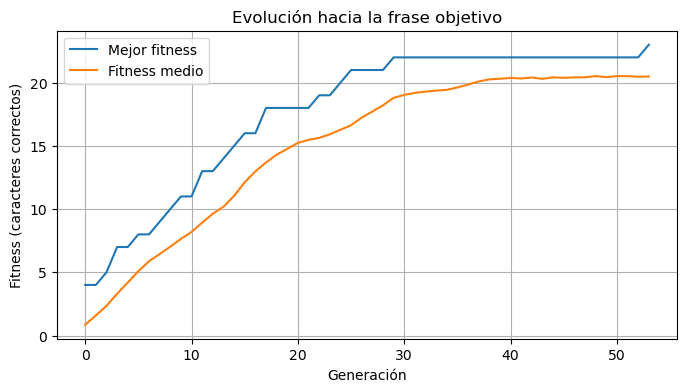

In [26]:
generations_p = [h['generation'] for h in history_phrase]
best_values_p = [h['best'] for h in history_phrase]
mean_values_p = [h['mean'] for h in history_phrase]

plt.figure(figsize=(8, 4))
plt.plot(generations_p, best_values_p, label='Mejor fitness')
plt.plot(generations_p, mean_values_p, label='Fitness medio')
plt.xlabel('Generación')
plt.ylabel('Fitness (caracteres correctos)')
plt.title('Evolución hacia la frase objetivo')
plt.legend()
plt.grid(True)
plt.show()

### Actividad 4 — Sin elitismo

Ejecuta el algoritmo con y sin elitismo. ¿Puede disminuir el mejor fitness de una generación a la siguiente? Explica el resultado.

Con elitismo -> mejor fitness final: 40
Sin elitismo -> mejor fitness final: 40
¿Bajó el mejor fitness en algún punto sin elitismo? True


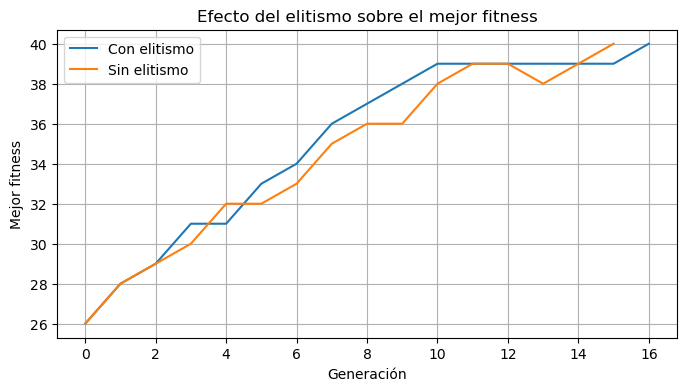

In [27]:
best_with, history_with = genetic_algorithm(
    chromosome_length=40, generations=150, elitism=True, seed=SEED,
)
best_without, history_without = genetic_algorithm(
    chromosome_length=40, generations=150, elitism=False, seed=SEED,
)

print('Con elitismo -> mejor fitness final:', history_with[-1]['best'])
print('Sin elitismo -> mejor fitness final:', history_without[-1]['best'])

decreased = any(
    history_without[i]['best'] < history_without[i - 1]['best']
    for i in range(1, len(history_without))
)
print('¿Bajó el mejor fitness en algún punto sin elitismo?', decreased)

plt.figure(figsize=(8, 4))
plt.plot([h['generation'] for h in history_with], [h['best'] for h in history_with], label='Con elitismo')
plt.plot([h['generation'] for h in history_without], [h['best'] for h in history_without], label='Sin elitismo')
plt.xlabel('Generación')
plt.ylabel('Mejor fitness')
plt.title('Efecto del elitismo sobre el mejor fitness')
plt.legend()
plt.grid(True)
plt.show()

Sí, puede bajar. Sin elitismo, el mejor individuo de una generación no se copia automáticamente a la siguiente: si no gana ningún torneo, o si es seleccionado pero el cruce/mutación lo altera, puede desaparecer de la población. Como se reporta el mejor individuo de la población actual en cada generación, el valor puede disminuir temporalmente respecto a la generación anterior. Con elitismo, en cambio, el mejor individuo siempre sobrevive intacto, así que la curva de mejor fitness nunca puede bajar (es monótona no decreciente).

## Preguntas de cierre

1. **¿Qué papel cumple la población que no existe en Hill Climbing?**

La población mantiene múltiples soluciones candidatas explorando el espacio de búsqueda al mismo tiempo, en vez de una sola. Esto le da al algoritmo diversidad genética para combinar (mediante el cruce) y le permite escapar de óptimos locales: aunque algunos individuos se queden atascados en una región mala, otros pueden estar explorando regiones distintas y mejores. Hill Climbing, al mantener un único estado, depende completamente de su vecindario inmediato y no tiene forma de "recordar" ni combinar información de otras zonas del espacio de búsqueda.

2. **¿Por qué el cruce no garantiza hijos mejores que sus padres?**

El cruce combina fragmentos de los cromosomas de dos padres, pero esa combinación es ciega respecto al fitness: no evalúa si el fragmento que aporta cada padre es realmente "bueno" en esa posición. Puede juntar fragmentos que funcionaban bien en el contexto de su cromosoma original, pero que al combinarse producen una solución peor (por ejemplo, rompiendo una secuencia de bits que ya estaba correcta). El cruce es una fuente de variación, no una operación de mejora garantizada; la selección por fitness es la que, a lo largo de varias generaciones, favorece que los buenos fragmentos se mantengan en la población.

3. **¿Qué significa convergencia prematura?**

Es cuando la población pierde diversidad demasiado rápido y todos los individuos se vuelven muy similares (o idénticos) antes de haber explorado suficientemente el espacio de búsqueda. Como consecuencia, el algoritmo queda atrapado en un óptimo local: el cruce entre individuos casi idénticos ya no genera variación útil, y sin mutación suficiente, la población no puede escapar de esa zona aunque no sea la solución óptima global.

4. **¿Qué parámetros controlan la exploración?**

- **Tasa de mutación (`mutation_rate`)**: a mayor tasa, más variación aleatoria se introduce, favoreciendo la exploración.
- **Tamaño del torneo (`tournament_size`)**: un torneo pequeño da más oportunidad a individuos débiles de ser seleccionados, manteniendo diversidad; un torneo grande aumenta la presión de selección hacia los mejores (más explotación).
- **Tasa de cruce (`crossover_rate`)**: cruces más frecuentes generan más combinaciones nuevas.
- **Tamaño de la población (`population_size`)**: una población más grande cubre más regiones del espacio de búsqueda simultáneamente.
- **Elitismo**: paradójicamente, favorece la explotación (conserva siempre lo mejor encontrado), por lo que desactivarlo o combinarlo con alta mutación favorece más exploración.